In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
# 1 og 2: Utforske og forstå datasettet

df = pd.read_csv("data/porto.csv")

df.head()


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [3]:
print(df.head())
print("(Antall rader, antall kolonner)",df.shape)

               TRIP_ID CALL_TYPE  ORIGIN_CALL  ORIGIN_STAND   TAXI_ID  \
0  1372636858620000589         C          NaN           NaN  20000589   
1  1372637303620000596         B          NaN           7.0  20000596   
2  1372636951620000320         C          NaN           NaN  20000320   
3  1372636854620000520         C          NaN           NaN  20000520   
4  1372637091620000337         C          NaN           NaN  20000337   

    TIMESTAMP DAY_TYPE  MISSING_DATA  \
0  1372636858        A         False   
1  1372637303        A         False   
2  1372636951        A         False   
3  1372636854        A         False   
4  1372637091        A         False   

                                            POLYLINE  
0  [[-8.618643,41.141412],[-8.618499,41.141376],[...  
1  [[-8.639847,41.159826],[-8.640351,41.159871],[...  
2  [[-8.612964,41.140359],[-8.613378,41.14035],[-...  
3  [[-8.574678,41.151951],[-8.574705,41.151942],[...  
4  [[-8.645994,41.18049],[-8.645949,41.180517

In [4]:
print(df.columns)

Index(['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID',
       'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE'],
      dtype='str')


In [5]:
# 3. Utforske Nan verdier

df.isna().sum()

TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
TIMESTAMP             0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
dtype: int64

In [6]:
pd.crosstab(
    df["CALL_TYPE"],
    df["ORIGIN_CALL"].isna(),
    rownames=["CALL_TYPE"],
    colnames=["ORIGIN_CALL missing"]
)


ORIGIN_CALL missing,False,True
CALL_TYPE,,
A,364770,0
B,0,817881
C,0,528019


In [7]:
pd.crosstab(
    df["CALL_TYPE"],
    df["ORIGIN_STAND"].isna(),
    rownames=["CALL_TYPE"],
    colnames=["ORIGIN_STAND missing"]
)

ORIGIN_STAND missing,False,True
CALL_TYPE,,
A,0,364770
B,806579,11302
C,0,528019


In [8]:
df["CALL_TYPE"].value_counts()

CALL_TYPE
B    817881
C    528019
A    364770
Name: count, dtype: int64

Gjennom analysen av NaN verdier hittil ser vi at det er en god del NaN verdier som mangler i ORIGIN_CALL og ORIGIN_STAND. Her kan man fort tenke at det er smart å kvitte seg med disse verdiene eller gjøre noe form for dataimputering, men før en beslutning må vi forstå hva kolonnene og potensielle Null verdier representerer.

Ifølge oppgaven er ORIGIN_CALL IDen til kunden som initierte samtalen, og har kun en verdi når CALL_TYPE = A, ellers null. ORIGIN_STAND er IDen til taxistanden hvor turen startet, og har en verdi kun hvis CALL_TYPE = B. Dette forteller oss at vi må se på relasjonen mellom CALL_TYPE og ORIGIN_STAND/CALL:

Vi lagde derfor to crosstabs som forteller oss hvor og når NaN verdier oppstår. Ifølge crosstaben ser vi at når CALL_TYPE = A så finnes det ingen NaN verdier i ORIGIN_CALL, men når den er B eller C er alle NaN. Dette henger med beskrivelsen av selve kolonnen. For ORIGIN_STAND er det fortsatt 11302 NaN verdier når CALL_TYPE = B. Disse verdiene er faktiske mangler i datasettet. Vi velger å beholde alle NaN verdier, også de som viser til faktiske mangler. Dette er fordi ORIGIN_STAND ikke er veldig sentralt i senere analyser, og ved å slette 11000 rader kan vi miste annen verdifull informasjon. Imputering er heller ikke relevant med tanke på at det ikke finnes en pålitelig måte å legge til ID-verdier.

In [9]:
print("Rows with missing GPS points:", df["MISSING_DATA"].sum())

Rows with missing GPS points: 10


MISSING_DATA forteller oss om det finnes turer som mangler GPS punkter, og vi ser at det finnes 10 turer med gps mangler. I senere analyser er POLYLINE sentralt fordi vi skal blant annet finne ut varighet, tid, distanse og lignende. Hvis vi mangler GPS-punkter, vet vi ikke om de manglende punktene ligger i starten, midten eller slutten av turen. Dermed kan vi heller ikke være sikre på at det faktisk er 15 sekunder mellom alle registrerte punkter i disse 10 radene. Imputering av gps punkter her vil heller ikke gå fordi vi ikke vet hvor manglene ligger. Vi velger derfor å slette disse 10 radene grunnet at dette vil øke påliteligheten til POLYLINE kolonnen, og det er så få rader at vi ikke mister masse verdifull data.

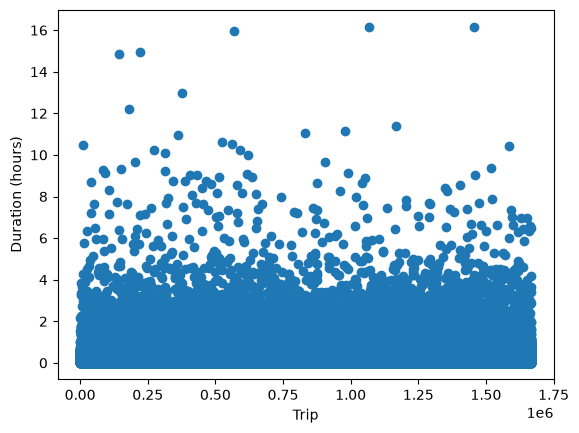

count    1666766.00
mean           0.20
std            0.19
min            0.01
25%            0.12
50%            0.17
75%            0.24
max           16.17
dtype: float64

In [20]:
# 4. Utforsking av datakarakteristikker

durations = []

for polyline in df["POLYLINE"]:
    points = json.loads(polyline)
    if len(points) >= 3:
        duration = (len(points) - 1) * 15 / 3600
        durations.append(duration)

plt.scatter(range(len(durations)), durations)
plt.xlabel("Trip")
plt.ylabel("Duration (hours)")
plt.show()


pd.Series(durations).describe().round(2)

In [16]:
point_counts = []

for polyline in df["POLYLINE"]:
    points = json.loads(polyline)
    point_counts.append(len(points))

point_series = pd.Series(point_counts)
print(point_series.describe())



count    1.710670e+06
mean     4.875831e+01
std      4.565372e+01
min      0.000000e+00
25%      2.800000e+01
50%      4.100000e+01
75%      5.900000e+01
max      3.881000e+03
dtype: float64


POLYLINE inneholder GPS punktene for hver tur, og er derfor viktig for flere av analysene senere. Vi undersøkte hvor mange GPS punkter hver tur har. En vanlig tur har rundt 41 GPS punkter i median, mens gjennomsnittet ligger på omtrent 49 punkter.  
Varigheten ble beregnet ut fra at det er 15 sekunder mellom hvert GPS punkt. For å få en mer pålitelig varighetsanalyse tok vi kun med turer med minst 3 GPS punkter. Medianen på varigheten er omtrent 0.17 timer, altså rundt 10 minutter, mens gjennomsnittet er omtrent 0.20 timer eller 12 minutter. De fleste turene er derfor relativt korte, men vi ser også noen tydelige outliers. Den lengste turen er på omtrent 16.17 timer, som skiller seg mye fra resten av datasettet. Vi velger likevel ikke å fjerne disse kun fordi de er outliers, siden vi ikke vet om de faktisk er feilregistreringer.

DAY_TYPE
A    1.0
Name: proportion, dtype: float64


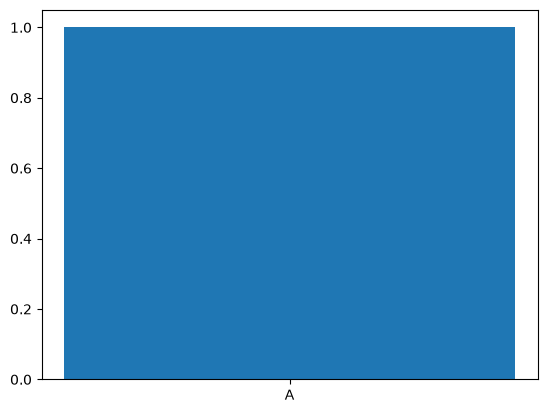

In [13]:
plt.bar(df["DAY_TYPE"].value_counts().index, df["DAY_TYPE"].value_counts(normalize=True))

print(df["DAY_TYPE"].value_counts(normalize=True))

Plottet DAY_TYPE for å se fordelingen mellom de ulike klassene, og vi ser at den alltid er A som vil si at det ikke er noe variasjon og behov for videre analyse.

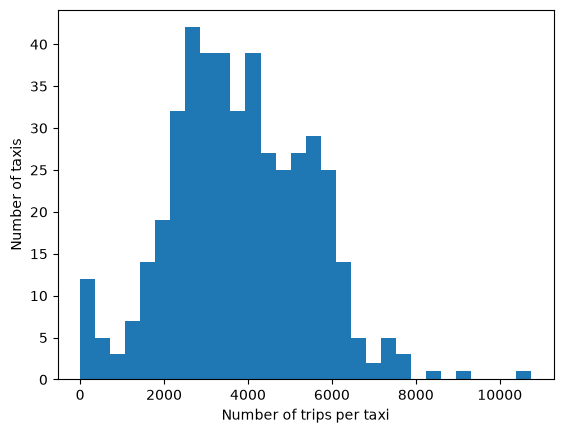

In [22]:
tur_per_taxi = df["TAXI_ID"].value_counts()

plt.hist(tur_per_taxi, bins=30)
plt.xlabel("Number of trips per taxi")
plt.ylabel("Number of taxis")
plt.show()

Fordelingen av antall turer per taxi viser at de fleste taxiene har mellom omtrent 2000 og 6000 turer. Det finnes også noen taxier med veldig få turer, og noen få med betydelig flere turer enn resten. Den høyeste ligger på over 10 000 turer, som skiller seg tydelig ut fra hoveddelen av datasettet.